# Healthcare EMR Analytics

Author: Pawan Manikanta Reddy

Tools Used:
- R
- Google Colab
- Excel

Project Objective:
Analyze clinical services EMR data to identify operational trends, patient satisfaction drivers, and opportunities for process improvement.

In [ ]:

suppressPackageStartupMessages({
  library(readxl)
  library(dplyr)
  library(ggplot2)
  library(tidyr)
  library(lubridate)
})

In [ ]:
# If you uploaded the file into Colab
data <- readxl::read_excel("/content/Clinical_Services_Synthetic_EMR_Data.xlsx")
head(data)

visit_id,program,site,visit_mode,appointment_created_date,scheduled_start_dt,check_in_dt,roomed_dt,seen_dt,visit_end_dt,⋯,service_type,language,interpreter_needed,insurance_type,age_group,zip_region,race,ethnicity,satisfaction_rating,issue_flag
<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<dttm>,<dttm>,<dttm>,<dttm>,⋯,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
V000001,Immunizations,Downtown,In-person,2025-09-24,2025-09-28 13:15:00,2025-09-28 13:07:00,2025-09-28 13:25:00,2025-09-28 13:31:00,2025-09-28 14:09:00,⋯,Follow-up,Spanish,TRUE,Private,0–4,Region C,Asian,Hispanic/Latino,4,None
V000002,WIC,South,In-person,2025-03-20,2025-04-02 15:00:00,2025-04-02 14:55:00,2025-04-02 15:08:00,2025-04-02 15:17:00,2025-04-02 15:53:00,⋯,New,English,FALSE,Private,0–4,Region B,White,Not Hispanic/Latino,3,None
V000003,STI Clinic,South,In-person,2025-01-12,2025-01-21 09:15:00,2025-01-21 09:11:00,2025-01-21 09:20:00,2025-01-21 09:32:00,2025-01-21 09:50:00,⋯,Follow-up,English,FALSE,Medicaid,5–17,Region C,White,Not Hispanic/Latino,5,None
V000004,STI Clinic,South,In-person,2025-08-24,2025-09-04 09:45:00,2025-09-04 09:36:00,2025-09-04 09:44:00,2025-09-04 09:51:00,2025-09-04 10:25:00,⋯,New,English,FALSE,Self-pay,25–49,Region C,Other/Multiple,Not Hispanic/Latino,5,None
V000005,STI Clinic,Downtown,In-person,2025-09-13,2025-09-14 09:15:00,NA,NA,NA,NA,⋯,Follow-up,Spanish,TRUE,Self-pay,0–4,Region C,Asian,Not Hispanic/Latino,NA,NA
V000006,WIC,Downtown,In-person,2025-01-08,2025-01-24 13:00:00,2025-01-24 12:55:00,2025-01-24 13:13:00,2025-01-24 13:13:00,2025-01-24 13:43:00,⋯,Counseling,English,FALSE,Medicaid,18–24,Region A,White,Not Hispanic/Latino,4,None


In [ ]:
summary(data)
colSums(is.na(data))

   visit_id           program              site            visit_mode       
 Length:1000        Length:1000        Length:1000        Length:1000       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
 appointment_created_date      scheduled_start_dt           
 Min.   :2024-11-27 00:00:00   Min.   :2025-01-01 11:15:00  
 1st Qu.:2025-03-19 00:00:00   1st Qu.:2025-04-02 05:22:30  
 Median :2025-06-16 12:00:00   Median :2025-07-04 00:07:30  
 Mean   :2025-06-17 23:34:04   Mean   :2025-07-02 19:22:58  
 3rd Qu.:2025-09-11 00:00:00   3rd Qu.:2025-09-26 13:33:45  
 Max.   :2025-12-2

visit_id                  program                     site 
                       0                        0                        0 
              visit_mode appointment_created_date       scheduled_start_dt 
                       0                        0                        0 
             check_in_dt                roomed_dt                  seen_dt 
                     214                      214                      214 
            visit_end_dt                   status            provider_role 
                     214                        0                      162 
             provider_id             service_type                 language 
                     170                        0                        0 
      interpreter_needed           insurance_type                age_group 
                       0                        0                        0 
              zip_region                     race                ethnicity 
                       0                        0                        0 
     satisfaction_rating               issue_flag 
                     214                      214

In [ ]:
data_clean <- data %>%
  filter(!is.na(scheduled_start_dt))
data_clean$scheduled_start_dt <- as.POSIXct(data_clean$scheduled_start_dt)
data_clean$check_in_dt <- as.POSIXct(data_clean$check_in_dt)
data_clean$seen_dt <- as.POSIXct(data_clean$seen_dt)
data_clean$visit_end_dt <- as.POSIXct(data_clean$visit_end_dt)
str(data_clean)

tibble [1,000 × 23] (S3: tbl_df/tbl/data.frame)
 $ visit_id                : chr [1:1000] "V000001" "V000002" "V000003" "V000004" ...
 $ program                 : chr [1:1000] "Immunizations" "WIC" "STI Clinic" "STI Clinic" ...
 $ site                    : chr [1:1000] "Downtown" "South" "South" "South" ...
 $ visit_mode              : chr [1:1000] "In-person" "In-person" "In-person" "In-person" ...
 $ appointment_created_date: POSIXct[1:1000], format: "2025-09-24" "2025-03-20" ...
 $ scheduled_start_dt      : POSIXct[1:1000], format: "2025-09-28 13:15:00" "2025-04-02 15:00:00" ...
 $ check_in_dt             : POSIXct[1:1000], format: "2025-09-28 13:07:00" "2025-04-02 14:55:00" ...
 $ roomed_dt               : POSIXct[1:1000], format: "2025-09-28 13:25:00" "2025-04-02 15:08:00" ...
 $ seen_dt                 : POSIXct[1:1000], format: "2025-09-28 13:31:00" "2025-04-02 15:17:00" ...
 $ visit_end_dt            : POSIXct[1:1000], format: "2025-09-28 14:09:00" "2025-04-02 15:53:00" ...
 $ 

In [ ]:

data_clean$wait_time <- as.numeric(
  difftime(data_clean$seen_dt, data_clean$check_in_dt, units = "mins")
)

data_clean$visit_duration <- as.numeric(
  difftime(data_clean$visit_end_dt, data_clean$seen_dt, units = "mins")
)

data_clean$Month <- format(data_clean$scheduled_start_dt, "%b")

head(data_clean)

visit_id,program,site,visit_mode,appointment_created_date,scheduled_start_dt,check_in_dt,roomed_dt,seen_dt,visit_end_dt,⋯,insurance_type,age_group,zip_region,race,ethnicity,satisfaction_rating,issue_flag,wait_time,visit_duration,Month
<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<dttm>,<dttm>,<dttm>,<dttm>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
V000001,Immunizations,Downtown,In-person,2025-09-24,2025-09-28 13:15:00,2025-09-28 13:07:00,2025-09-28 13:25:00,2025-09-28 13:31:00,2025-09-28 14:09:00,⋯,Private,0–4,Region C,Asian,Hispanic/Latino,4,None,24,38,Sep
V000002,WIC,South,In-person,2025-03-20,2025-04-02 15:00:00,2025-04-02 14:55:00,2025-04-02 15:08:00,2025-04-02 15:17:00,2025-04-02 15:53:00,⋯,Private,0–4,Region B,White,Not Hispanic/Latino,3,None,22,36,Apr
V000003,STI Clinic,South,In-person,2025-01-12,2025-01-21 09:15:00,2025-01-21 09:11:00,2025-01-21 09:20:00,2025-01-21 09:32:00,2025-01-21 09:50:00,⋯,Medicaid,5–17,Region C,White,Not Hispanic/Latino,5,None,21,18,Jan
V000004,STI Clinic,South,In-person,2025-08-24,2025-09-04 09:45:00,2025-09-04 09:36:00,2025-09-04 09:44:00,2025-09-04 09:51:00,2025-09-04 10:25:00,⋯,Self-pay,25–49,Region C,Other/Multiple,Not Hispanic/Latino,5,None,15,34,Sep
V000005,STI Clinic,Downtown,In-person,2025-09-13,2025-09-14 09:15:00,NA,NA,NA,NA,⋯,Self-pay,0–4,Region C,Asian,Not Hispanic/Latino,NA,NA,NA,NA,Sep
V000006,WIC,Downtown,In-person,2025-01-08,2025-01-24 13:00:00,2025-01-24 12:55:00,2025-01-24 13:13:00,2025-01-24 13:13:00,2025-01-24 13:43:00,⋯,Medicaid,18–24,Region A,White,Not Hispanic/Latino,4,None,18,30,Jan


In [ ]:
library(dplyr)

monthly_visits <- data_clean %>%
  group_by(Month) %>%
  summarise(visits = n())

program_load <- data_clean %>%
  group_by(program) %>%
  summarise(
    total_visits = n(),
    avg_wait = mean(wait_time, na.rm = TRUE),
    avg_duration = mean(visit_duration, na.rm = TRUE)
  )

satisfaction <- data_clean %>%
  summarise(avg_rating = mean(satisfaction_rating, na.rm = TRUE))

monthly_visits
program_load
satisfaction

Month,visits
<chr>,<int>
Apr,65
Aug,75
Dec,75
Feb,71
Jan,87
Jul,94
Jun,85
Mar,87
May,93


program,total_visits,avg_wait,avg_duration
<chr>,<int>,<dbl>,<dbl>
Immunizations,370,16.82394,22.00704
STI Clinic,344,19.35740,30.78700
WIC,286,19.40889,31.78667


avg_rating
<dbl>
4.026718


In [ ]:
data_clean <- data_clean %>%
  filter(!is.na(wait_time), !is.na(visit_duration))

In [ ]:

kpi_summary <- list(
  total_visits = nrow(data_clean),
  avg_wait_time = mean(data_clean$wait_time, na.rm = TRUE),
  avg_visit_duration = mean(data_clean$visit_duration, na.rm = TRUE),
  avg_satisfaction = mean(data_clean$satisfaction_rating, na.rm = TRUE)
)

kpi_summary

$total_visits
[1] 786

$avg_wait_time
[1] 18.45674

$avg_visit_duration
[1] 27.90076

$avg_satisfaction
[1] 4.026718

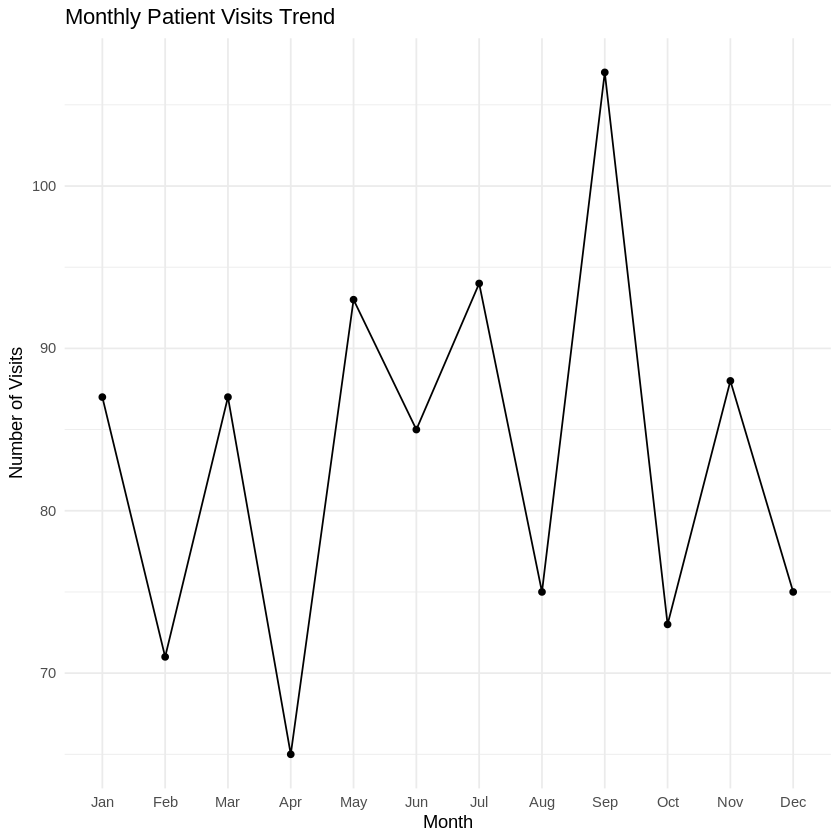

In [ ]:
ggplot(monthly_visits, aes(x = factor(Month, levels = c("Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec")),
                           y = visits, group = 1)) +
  geom_line() +
  geom_point() +
  ggtitle("Monthly Patient Visits Trend")+
  theme_minimal()+
  labs(x = "Month", y = "Number of Visits")

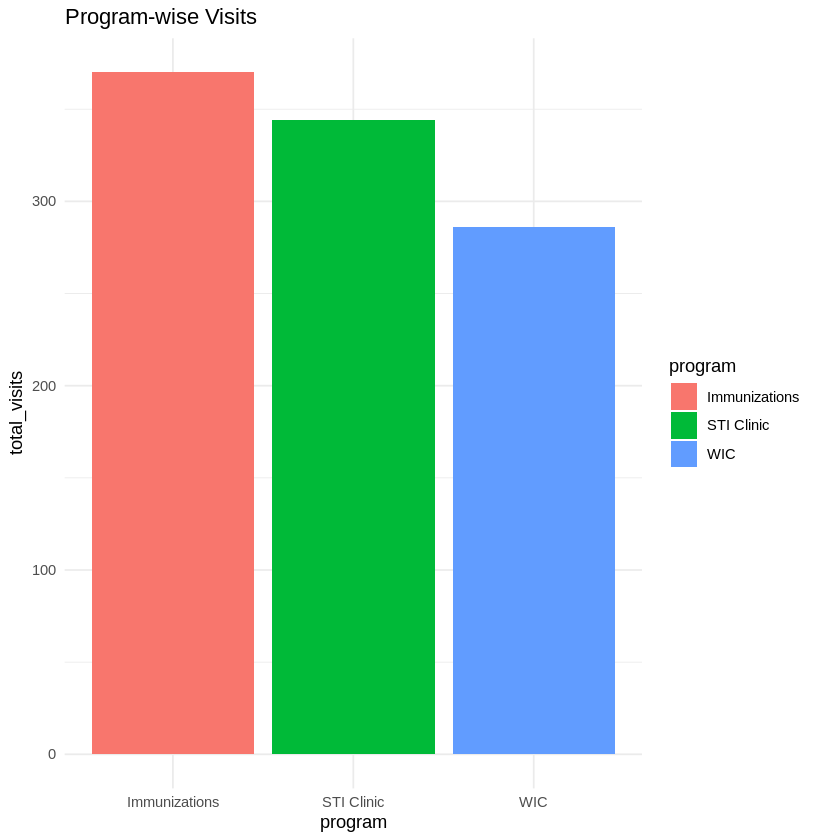

In [ ]:
ggplot(program_load, aes(x = program, y = total_visits, fill = program)) +
  geom_bar(stat = "identity") +
  ggtitle("Program-wise Visits") +
  theme_minimal()

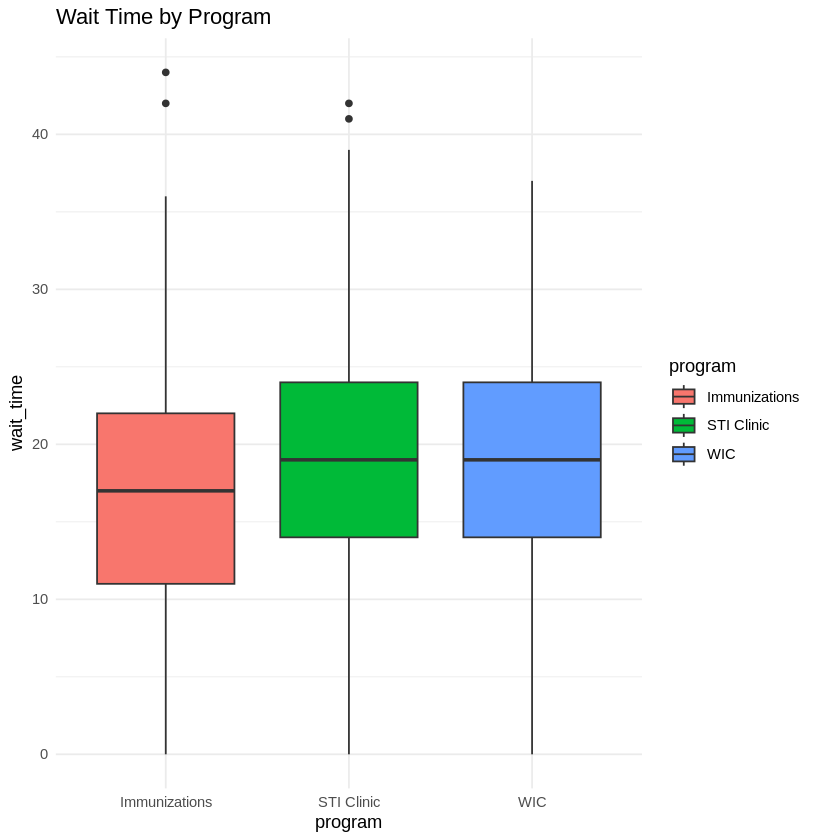

In [ ]:
ggplot(data_clean, aes(x = program, y = wait_time, fill = program)) +
  geom_boxplot() +
  ggtitle("Wait Time by Program")+
  theme_minimal()

In [ ]:
kpi_table <- data.frame(
  Metric = c("Total Visits", "Avg Wait Time", "Avg Duration", "Avg Satisfaction"),
  Value = c(
    kpi_summary$total_visits,
    paste0(sprintf("%.2f", kpi_summary$avg_wait_time), " mins"),
    paste0(sprintf("%.2f", kpi_summary$avg_visit_duration), " mins"),
    sprintf("%.2f", kpi_summary$avg_satisfaction)
  )
)

kpi_table

Metric,Value
<chr>,<chr>
Total Visits,786
Avg Wait Time,18.46 mins
Avg Duration,27.90 mins
Avg Satisfaction,4.03


In [ ]:
# STEP 1: Better KPI

kpi_wait <- data_clean %>%
  summarise(
    avg_wait = mean(wait_time, na.rm = TRUE),
    pct_over_30 = mean(wait_time > 30, na.rm = TRUE) * 100
  )

print(kpi_wait)

# A tibble: 1 × 2
  avg_wait pct_over_30
     <dbl>       <dbl>
1     18.5        7.51


In [ ]:
# STEP 2: Program comparison

program_analysis <- data_clean %>%
  group_by(program) %>%
  summarise(
    avg_wait = mean(wait_time, na.rm = TRUE),
    avg_satisfaction = mean(satisfaction_rating, na.rm = TRUE),
    total_visits = n()
  ) %>%
  arrange(desc(avg_wait))

print(program_analysis)

# A tibble: 3 × 4
  program       avg_wait avg_satisfaction total_visits
  <chr>            <dbl>            <dbl>        <int>
1 WIC               19.4             3.96          225
2 STI Clinic        19.4             3.98          277
3 Immunizations     16.8             4.12          284


In [ ]:
# STEP 3: Wait time vs satisfaction

correlation <- cor(data_clean$wait_time, data_clean$satisfaction_rating, use = "complete.obs")
print(correlation)

[1] -0.607039


`geom_smooth()` using formula = 'y ~ x'


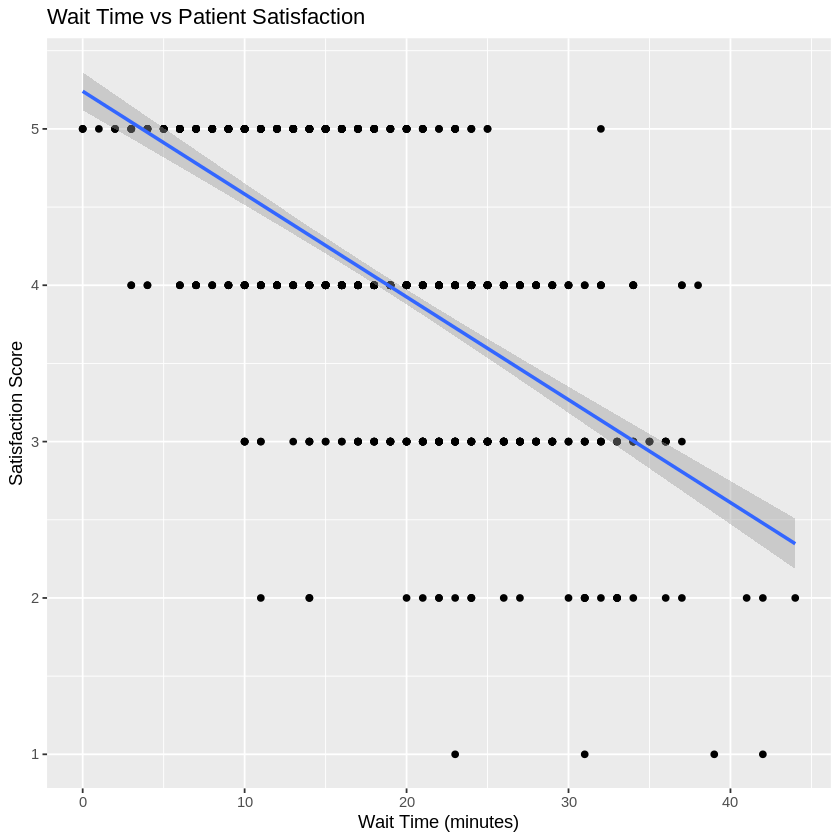

In [ ]:
# STEP 4: Plot relationship

ggplot(data_clean, aes(x = wait_time, y = satisfaction_rating)) +
  geom_point() +
  geom_smooth(method = "lm") +
  labs(
    title = "Wait Time vs Patient Satisfaction",
    x = "Wait Time (minutes)",
    y = "Satisfaction Score"
  )

In [ ]:
# STEP 5: Extract hour

data_clean$hour <- lubridate::hour(data_clean$check_in_dt)

In [ ]:
# STEP 6: Visits by hour

hourly_visits <- data_clean %>%
  group_by(hour) %>%
  summarise(visits = n())

print(hourly_visits)

# A tibble: 10 × 2
    hour visits
   <int>  <int>
 1     7     19
 2     8     63
 3     9    100
 4    10    120
 5    11     76
 6    12     74
 7    13    118
 8    14    103
 9    15     84
10    16     29


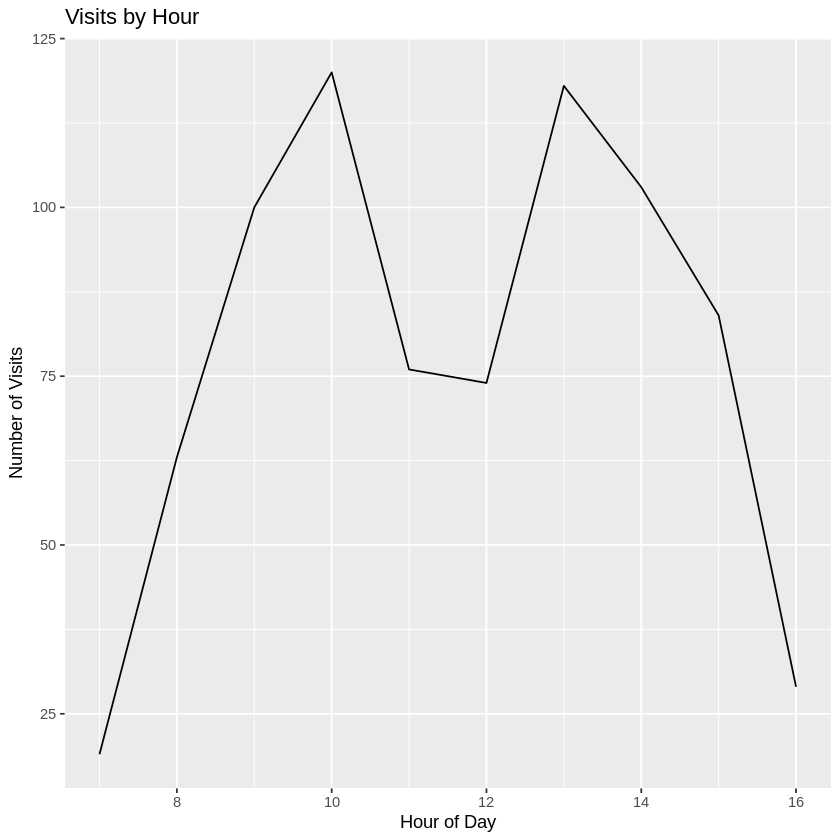

In [ ]:
# STEP 7: Plot hourly visits

ggplot(hourly_visits, aes(x = hour, y = visits)) +
  geom_line() +
  labs(
    title = "Visits by Hour",
    x = "Hour of Day",
    y = "Number of Visits"
  )